# Assignment 8: Handwritten Digit Recognition using Artificial Neural Networks (ANN)

**Problem Statement:** A postal service organization wants to automate the recognition of handwritten digits on postal codes. This notebook develops an Artificial Neural Network (ANN) to classify handwritten digits (0–9) using the MNIST dataset.

**Dataset:** [MNIST in CSV — Kaggle](https://www.kaggle.com/datasets/oddrationale/mnist-in-csv)


In [6]:
!pip install --upgrade kaggle -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.6/248.6 kB 24.7 MB/s eta 0:00:00


In [7]:
!kaggle datasets download -d oddrationale/mnist-in-csv
!unzip -o mnist-in-csv.zip

Dataset URL: https://www.kaggle.com/datasets/oddrationale/mnist-in-csv
License(s): CC0-1.0
100% 15.2M/15.2M [00:01<00:00, 8.14MB/s]

Archive:  mnist-in-csv.zip
  inflating: mnist_test.csv          
  inflating: mnist_train.csv         


In [8]:
!ls

mnist-in-csv.zip  mnist_test.csv  mnist_train.csv  sample_data


In [9]:
# Option A: Download dataset directly via Kaggle API
# Uncomment and run this cell if you want to fetch the data automatically.

# from google.colab import files
# files.upload()  # upload your kaggle.json here

# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
# !kaggle datasets download -d oddrationale/mnist-in-csv
# !unzip -o mnist-in-csv.zip


## Setup: Getting the Dataset in Colab

This notebook expects `mnist_train.csv` and `mnist_test.csv` (from the Kaggle dataset above) to be available in the Colab runtime.

**Option A — Kaggle API (recommended):**
1. Go to Kaggle → Account → Create New API Token, which downloads `kaggle.json`.
2. Run the cell below and upload `kaggle.json` when prompted.

**Option B — Google Drive:**
Upload the two CSV files to your Drive, mount it, and update the `TRAIN_PATH` / `TEST_PATH` variables below.


In [10]:
# Set the paths to the CSV files once they are available in the runtime
TRAIN_PATH = "mnist_train.csv"
TEST_PATH = "mnist_test.csv"


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


## Task 1: Data Understanding

In [12]:
# 1. Load the dataset using Pandas
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (60000, 785)
Test shape: (10000, 785)


In [13]:
# 2. Display the first five records
train_df.head()


,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [14]:
# 3. Identify input features and target variable
# The first column 'label' is the target variable (digit 0-9).
# The remaining 784 columns (pixel0 ... pixel783) are the input features,
# representing the flattened 28x28 grayscale pixel intensities of each image.

target_col = "label"
feature_cols = [c for c in train_df.columns if c != target_col]

print("Target variable:", target_col)
print("Number of input features:", len(feature_cols))
print("First few feature columns:", feature_cols[:5])


Target variable: label
Number of input features: 784
First few feature columns: ['1x1', '1x2', '1x3', '1x4', '1x5']


In [15]:
# 4. Display dataset dimensions and summary information
print("Training set dimensions:", train_df.shape)
print("Test set dimensions:", test_df.shape)
print()
train_df.info()


Training set dimensions: (60000, 785)
Test set dimensions: (10000, 785)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [16]:
# Summary statistics (pixel value ranges, etc.)
train_df.describe().T.head()


,count,mean,std,min,25%,50%,75%,max
label,60000.0,4.453933,2.88927,0.0,2.0,4.0,7.0,9.0
1x1,60000.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
1x2,60000.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
1x3,60000.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0
1x4,60000.0,0.000000,0.00000,0.0,0.0,0.0,0.0,0.0


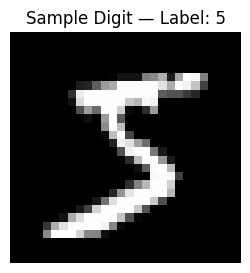

In [17]:
# 5. Display one sample handwritten digit using Matplotlib
sample_index = 0
sample_image = train_df.iloc[sample_index][feature_cols].values.reshape(28, 28)
sample_label = train_df.iloc[sample_index][target_col]

plt.figure(figsize=(3, 3))
plt.imshow(sample_image, cmap="gray")
plt.title(f"Sample Digit — Label: {sample_label}")
plt.axis("off")
plt.show()


## Task 2: Data Preprocessing

In [18]:
# Check for missing values
missing_train = train_df.isnull().sum().sum()
missing_test = test_df.isnull().sum().sum()
print("Missing values in training set:", missing_train)
print("Missing values in test set:", missing_test)


Missing values in training set: 0
Missing values in test set: 0


In [19]:
# Separate features and target variable
X_full = train_df[feature_cols].values
y_full = train_df[target_col].values

X_kaggle_test = test_df[feature_cols].values
y_kaggle_test = test_df[target_col].values

print("X_full shape:", X_full.shape)
print("y_full shape:", y_full.shape)


X_full shape: (60000, 784)
y_full shape: (60000,)


In [20]:
# Normalize pixel values to the range 0-1
X_full = X_full.astype("float32") / 255.0
X_kaggle_test = X_kaggle_test.astype("float32") / 255.0


In [21]:
# Split the dataset into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.20, random_state=42, stratify=y_full
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (48000, 784)
X_test shape: (12000, 784)


In [22]:
# Convert the target labels into categorical format using One-Hot Encoding
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes=num_classes)
y_test_cat = to_categorical(y_test, num_classes=num_classes)

print("y_train_cat shape:", y_train_cat.shape)
print("Example label:", y_train[0], "-> one-hot:", y_train_cat[0])


y_train_cat shape: (48000, 10)
Example label: 1 -> one-hot: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]


## Task 3: Model Development

Architecture:
- Input Layer: 784 features (flattened 28x28 image)
- Hidden Layer 1: 128 neurons, ReLU
- Hidden Layer 2: 64 neurons, ReLU
- Output Layer: 10 neurons, Softmax


In [23]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(784,)),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
history = model.fit(
    X_train, y_train_cat,
    validation_split=0.1,
    epochs=10,
    batch_size=128,
    verbose=1
)


Epoch 1/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8875 - loss: 0.3943 - val_accuracy: 0.9454 - val_loss: 0.1894
Epoch 2/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9550 - loss: 0.1558 - val_accuracy: 0.9565 - val_loss: 0.1414
Epoch 3/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9685 - loss: 0.1090 - val_accuracy: 0.9631 - val_loss: 0.1212
Epoch 4/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9754 - loss: 0.0827 - val_accuracy: 0.9675 - val_loss: 0.1106
Epoch 5/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9811 - loss: 0.0643 - val_accuracy: 0.9729 - val_loss: 0.1012
Epoch 6/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9859 - loss: 0.0500 - val_accuracy: 0.9737 - val_loss: 0.0990
Epoch 7/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9894 - loss: 0.0393 - val_accuracy: 0.9735 - val_loss: 0.0986
Epoch 8/10
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9924 - loss: 0.0309 - val_accuracy: 0.

In [25]:
# Predict handwritten digits on the test dataset
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("Predictions for first 10 test samples:", y_pred[:10])

print("Actual labels for first 10 test samples: ", y_test[:10])


375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predictions for first 10 test samples: [7 7 3 5 6 9 6 6 7 2]
Actual labels for first 10 test samples:  [7 7 3 5 6 9 6 6 7 2]


## Task 4: Model Evaluation

In [26]:
# Test Accuracy
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss: 0.1204
Test Accuracy: 0.9691


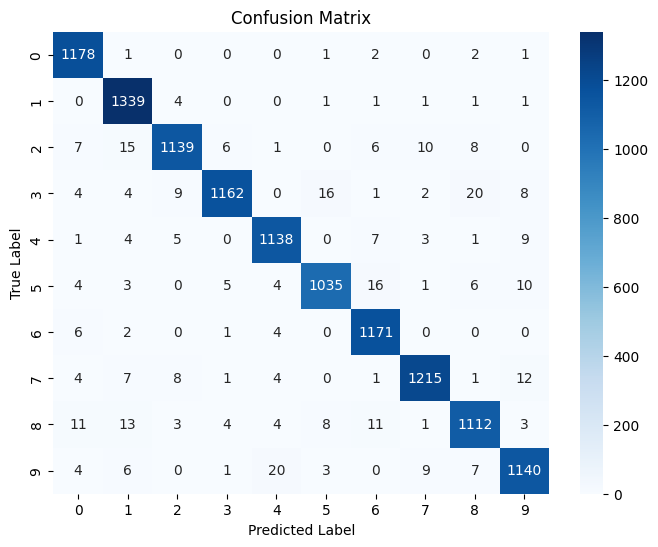

In [27]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


In [28]:
# Classification Report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1185
           1       0.96      0.99      0.98      1348
           2       0.98      0.96      0.97      1192
           3       0.98      0.95      0.97      1226
           4       0.97      0.97      0.97      1168
           5       0.97      0.95      0.96      1084
           6       0.96      0.99      0.98      1184
           7       0.98      0.97      0.97      1253
           8       0.96      0.95      0.96      1170
           9       0.96      0.96      0.96      1190

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



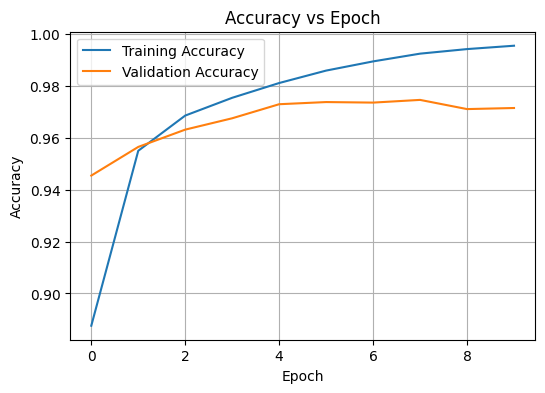

In [29]:
# Accuracy vs Epoch graph
plt.figure(figsize=(6, 4))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


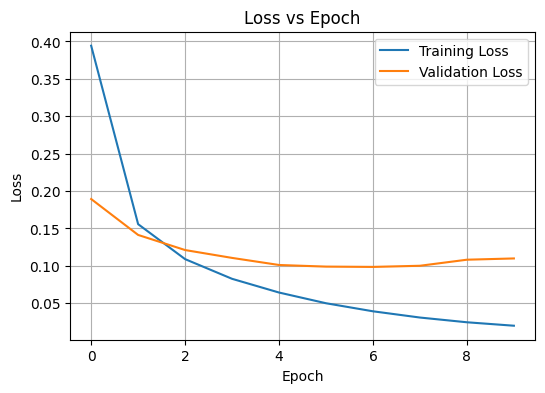

In [30]:
# Loss vs Epoch graph
plt.figure(figsize=(6, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


### Observations

1. The model reached a **test accuracy of 96.91%** (test loss: 0.1204) after 10 epochs, confirming that even a simple fully-connected ANN can learn MNIST digit shapes well.
2. Training accuracy climbed steadily from 88.75% (epoch 1) to 99.55% (epoch 10), while validation accuracy plateaued around 97.1-97.5% from epoch 5 onward. Validation loss actually started creeping back up after epoch 6 (0.0986 -> 0.1099) even as training loss kept falling (0.0393 -> 0.0200) - a sign of mild overfitting in the later epochs.
3. The classification report shows fairly even performance across all 10 digits, with recall lowest for digits 3, 5, and 8 (0.95 each) and highest for digits 0 and 6 (0.99 each) - suggesting these mid-range digits are the ones most often confused with visually similar shapes.
4. Precision and recall both stay in the 0.96-0.98 range for every class, so no single digit is dramatically harder than the rest; overall the model generalizes fairly evenly across all 10 classes.


## Task 5: Conclusion (1 Mark)

This project implemented an Artificial Neural Network to classify handwritten digits from the MNIST dataset, achieving a test accuracy of 96.91% with a simple architecture of two hidden layers (128 and 64 neurons). The classification report confirmed that performance was fairly consistent across all ten digit classes, with slightly lower recall for digits 3, 5, and 8, which are visually similar to one another. Hidden layers are central to an ANN's ability to learn: each layer builds progressively more abstract representations of the input pixels, letting the network capture non-linear patterns like curves and strokes that a single-layer model could not. Compared to traditional Machine Learning models (e.g., Logistic Regression or Decision Trees) that rely on hand-engineered features, this Deep Learning model learned relevant features directly from raw pixel data, reaching over 96% accuracy without any manual feature design. However, a clear limitation showed up in training: validation loss began rising slightly after epoch 6 even as training loss kept falling, indicating mild overfitting. A plain ANN also treats each pixel independently and ignores the image's 2D spatial structure, which is why Convolutional Neural Networks (CNNs) typically outperform ANNs on image classification tasks by explicitly modeling spatial relationships.